## Setup and import dataset

In [1]:
import pandas as pd

pd.set_option('display.max_columns', 50)

cols = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]


data = pd.read_csv('adult.data', names = cols, na_values='?', skipinitialspace=True, header=None)

## Initial Exploration

In [2]:
print(data.shape)
print(data.columns)
data.head()
data.info()
print(data.describe())

(32561, 15)
Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-

## Identifying unknown values

In [3]:
print(data['native-country'].value_counts(dropna=False))

native-country
United-States                 29170
Mexico                          643
NaN                             583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

## Missing Values

In [4]:
print(data.isna().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


## Cleaning up data

There are three usual methods for handling missing/unknown values:

drop, flag, fill



In [5]:
# Drop rows with missing values
data_dropped = data.dropna()

Filling with flag word like 'Unknown'

In [6]:
# Replace missing values with 'Unknown'
data.fillna('Unknown', inplace=True)
# Check that there are no more missing values
print(data.isna().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


This method is better practice than dropping rows because we keep more data which is always better.

## Categorical/Binary Columns

In [7]:
# Finding any weird category values
for col in data.select_dtypes(include='object').columns:
    print(f"Column: {col}")
    print(data[col].value_counts())
    print()

Column: workclass
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
Unknown              1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

Column: education
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

Column: marital-status
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

Column: occupation
occ

Notice that this dataset happened to be pretty clean already but this is an important step for any dataset that you are working with.

## Removing Duplicates

In [8]:
duplicates = data.duplicated().sum()
print(f"Duplicates: {duplicates}")
# data.drop_duplicates(inplace=True)
# print(f"Duplicates: {duplicates}")

Duplicates: 24


## Data Type Conversions

In [9]:
print(data.dtypes)

# Ensure numerical columns are of numeric type
# num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
# data[num_cols] = data[num_cols].apply(pd.to_numeric, errors='coerce')


age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object


## Saving clean dataset

In [10]:
data.to_csv('adult_clean.csv', index=False)

## EDA

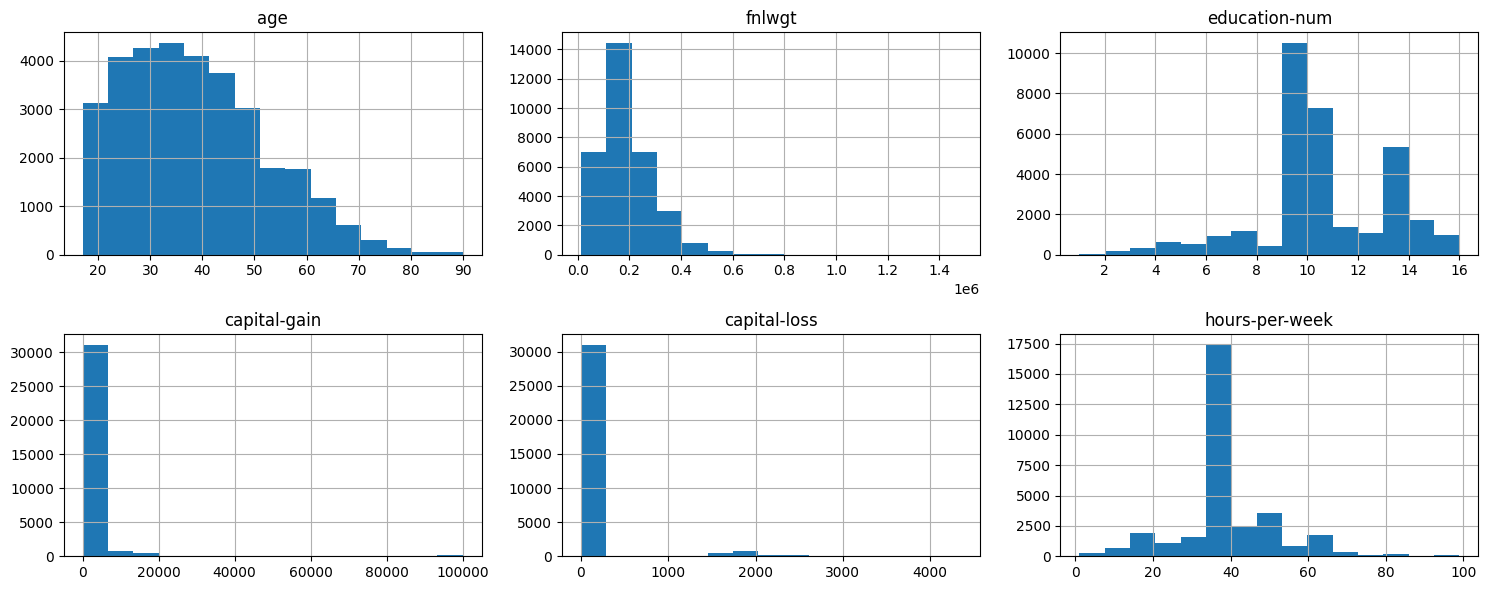

In [11]:
# Univariate analysis for numerical columns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]
df = pd.read_csv('adult_clean.csv', skipinitialspace=True)
num_cols = df.select_dtypes(include='number').columns
df[num_cols].hist(bins=15, figsize=(15, 6), layout=(2, 3))
plt.tight_layout()
plt.show()

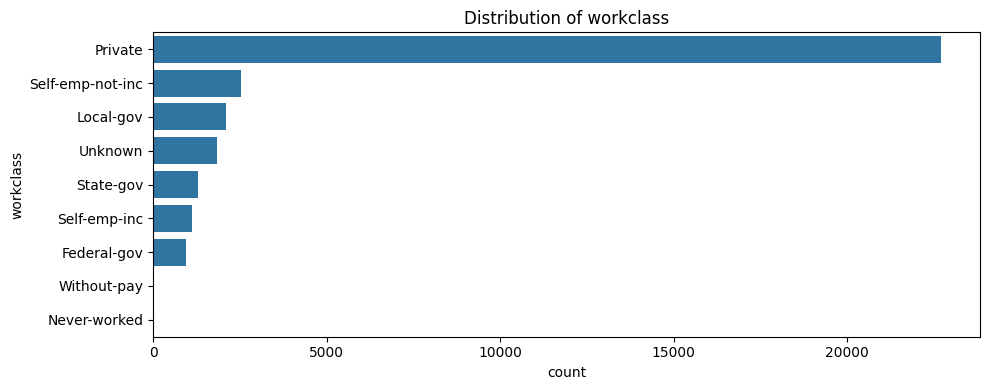

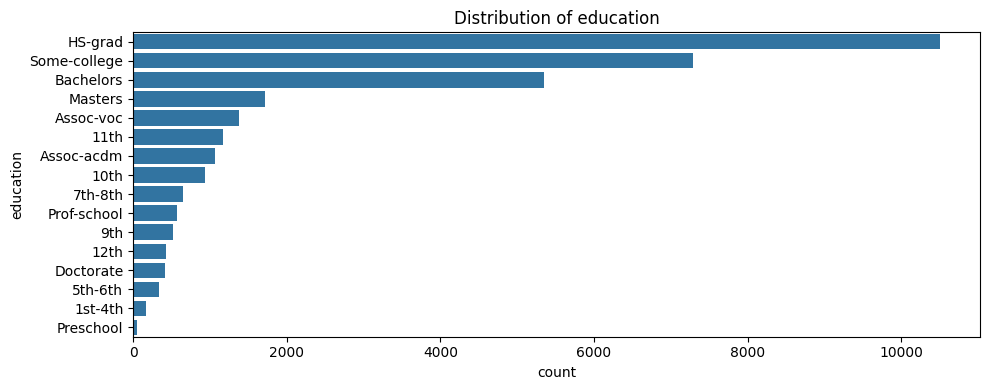

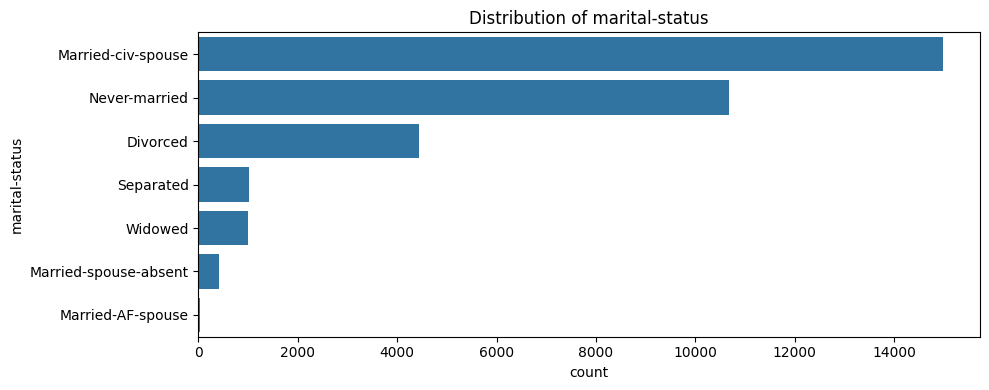

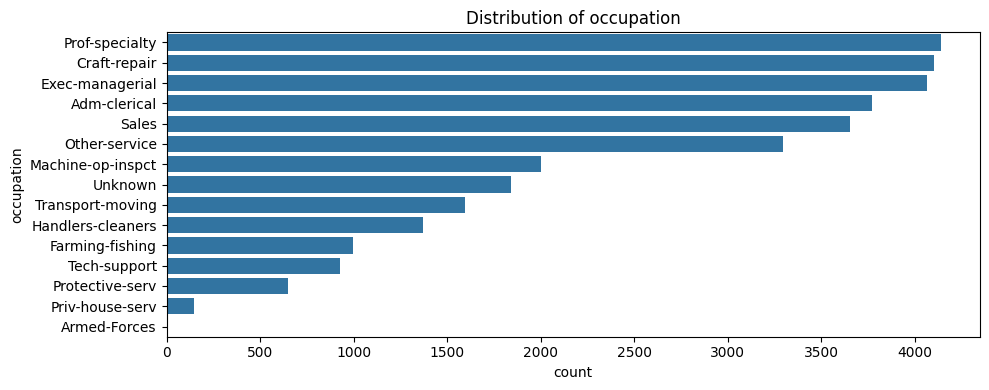

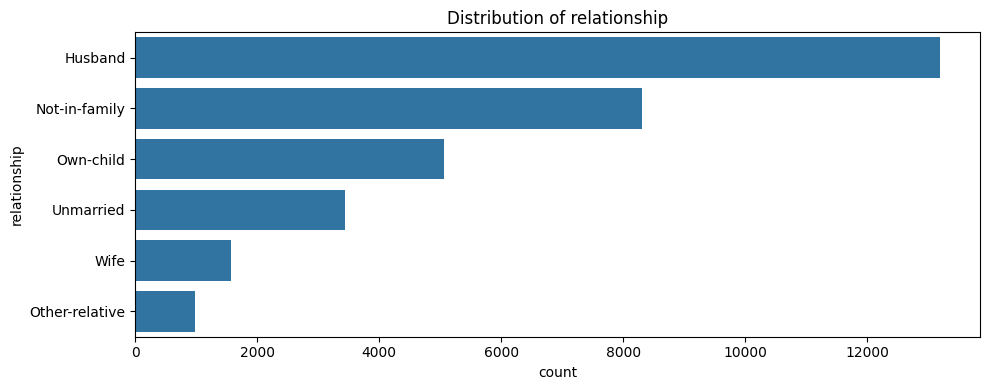

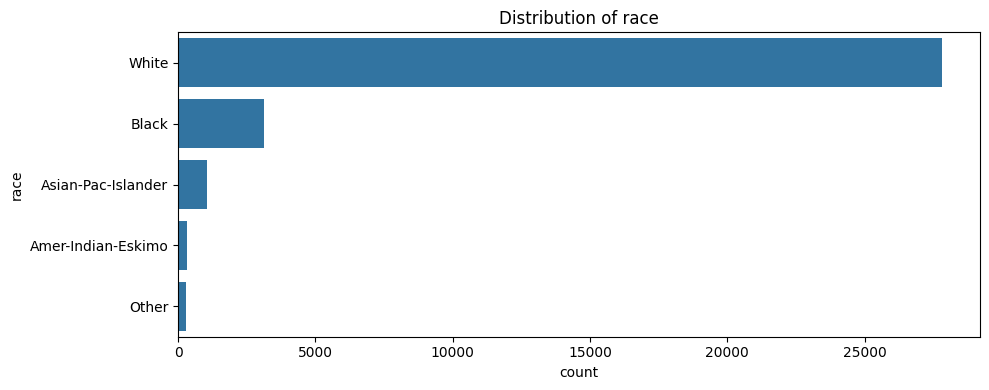

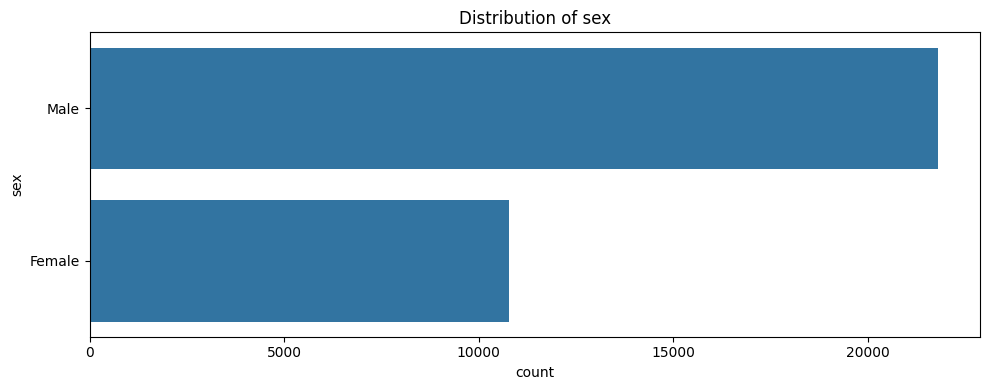

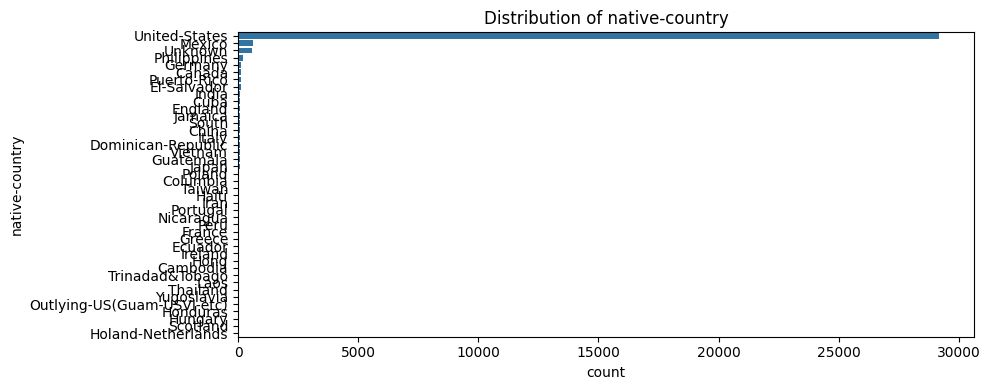

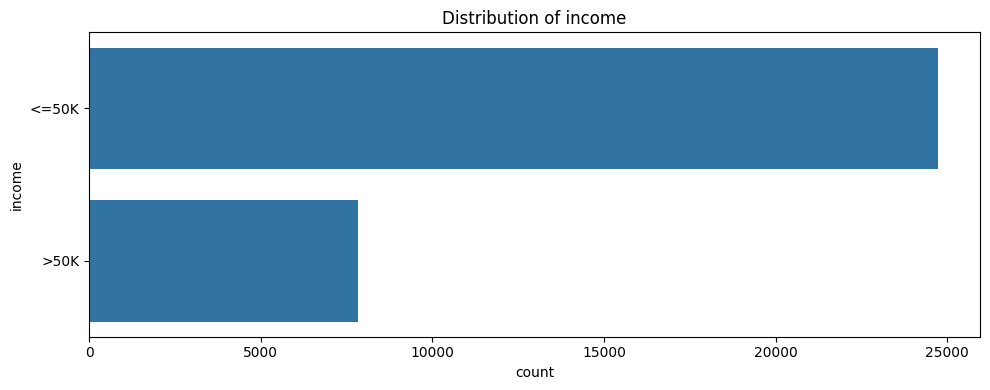

In [12]:
catergorical_cols = df.select_dtypes(include='object').columns
for col in catergorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

### Bivariate Analysis

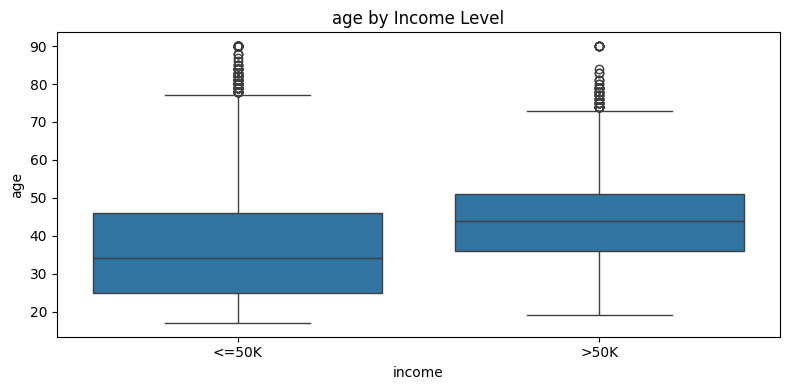

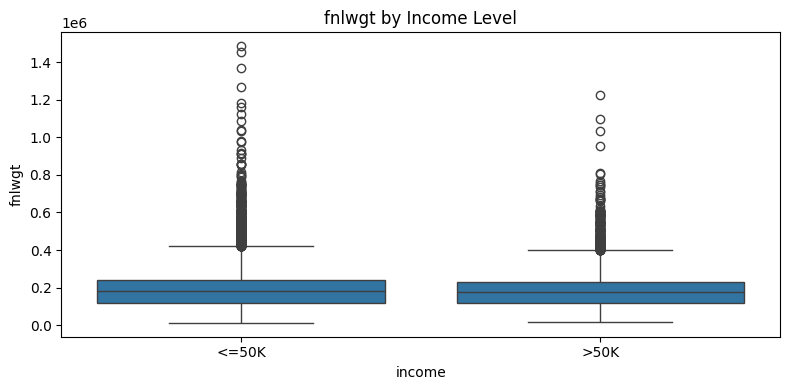

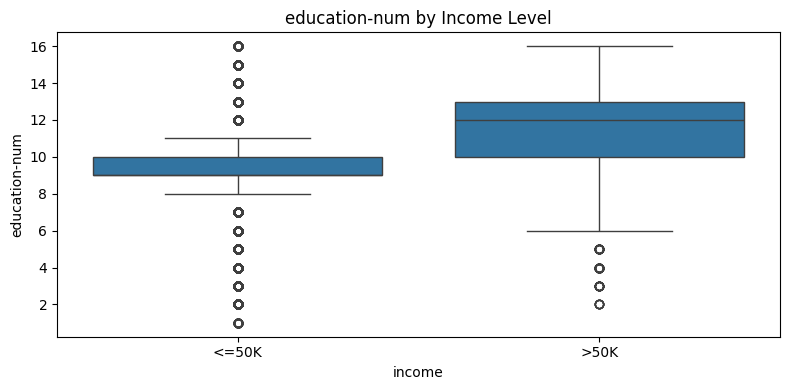

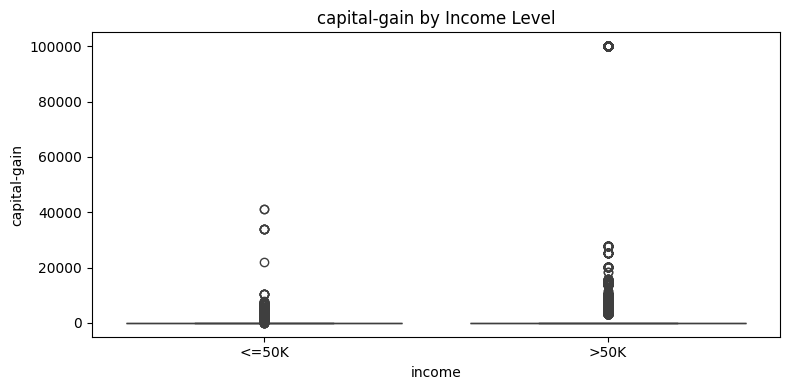

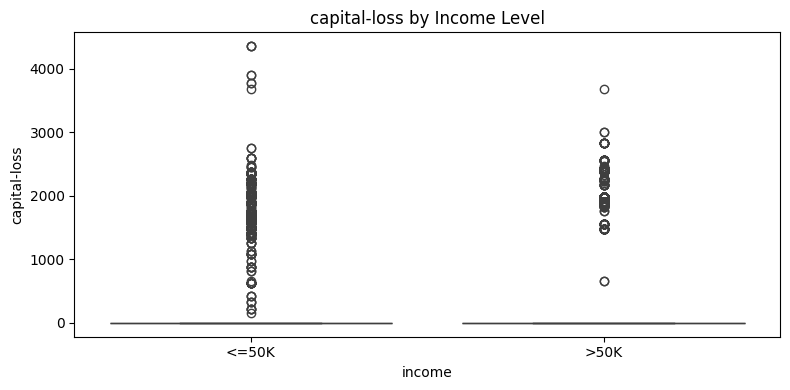

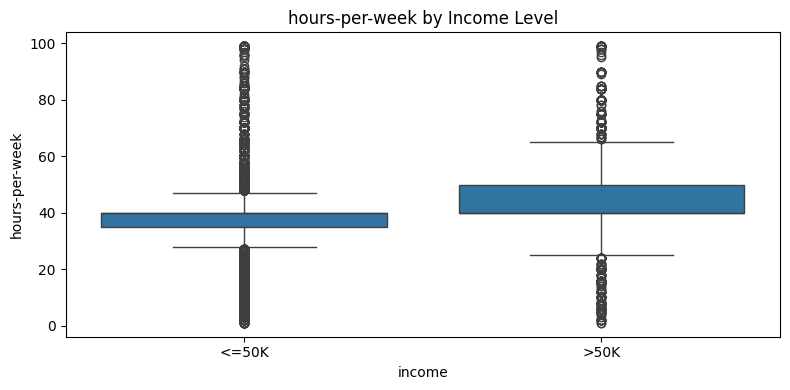

In [13]:
# Numerical vs Target variable analysis
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='income', y=col, data=df)
    plt.title(f'{col} by Income Level')
    plt.tight_layout()
    plt.show()

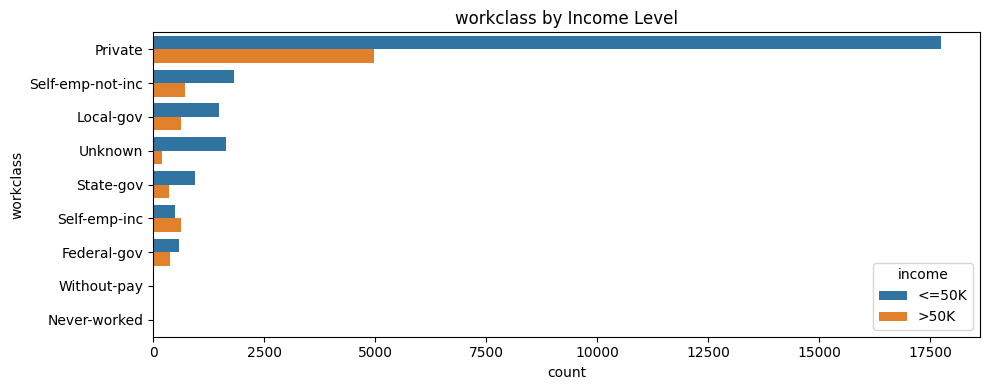

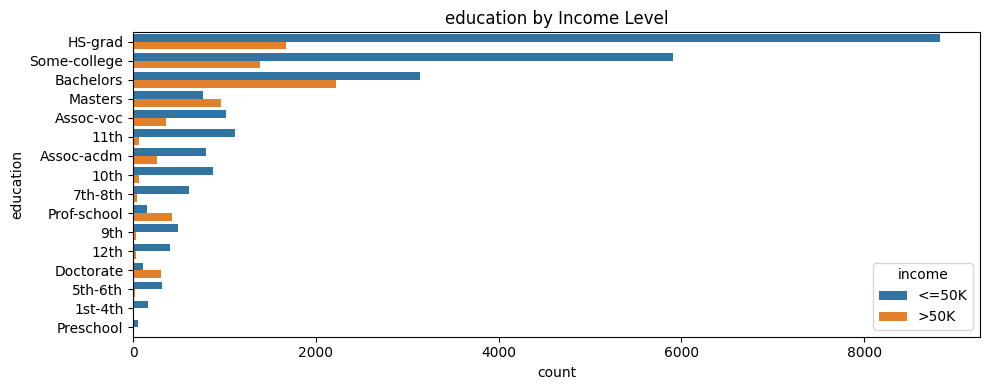

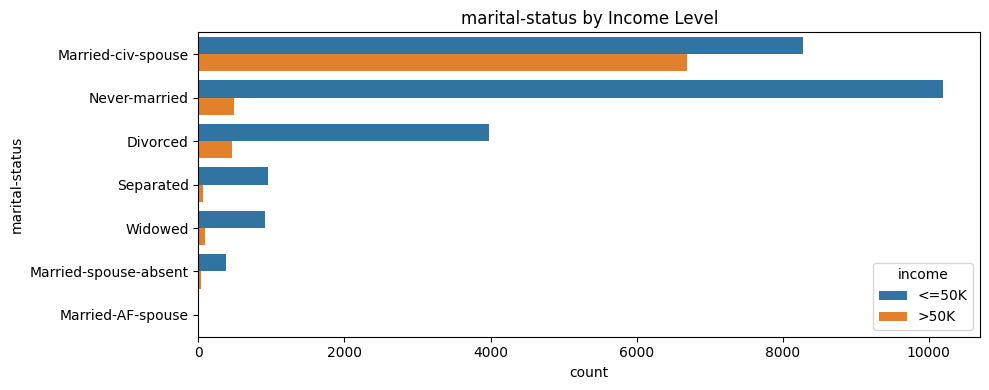

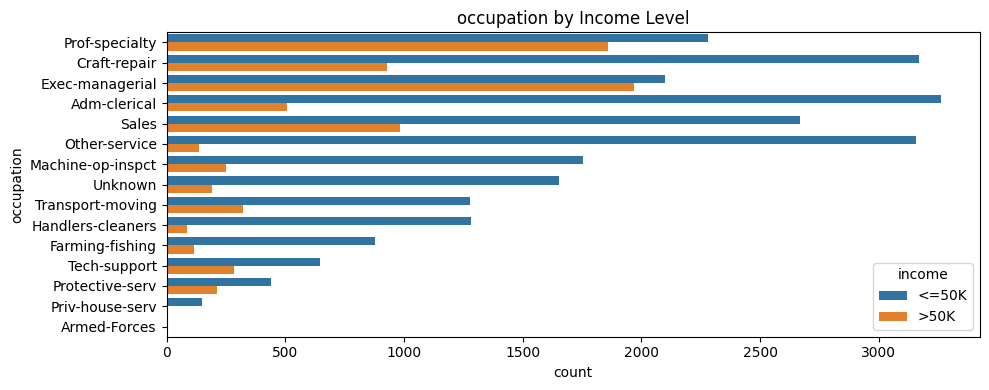

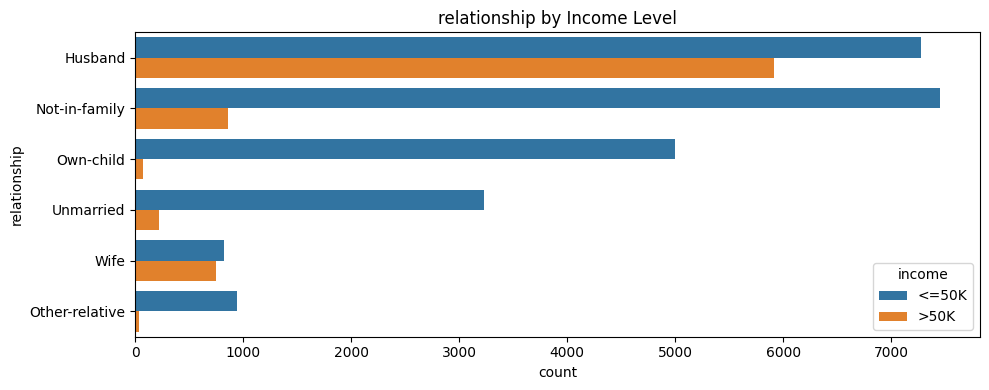

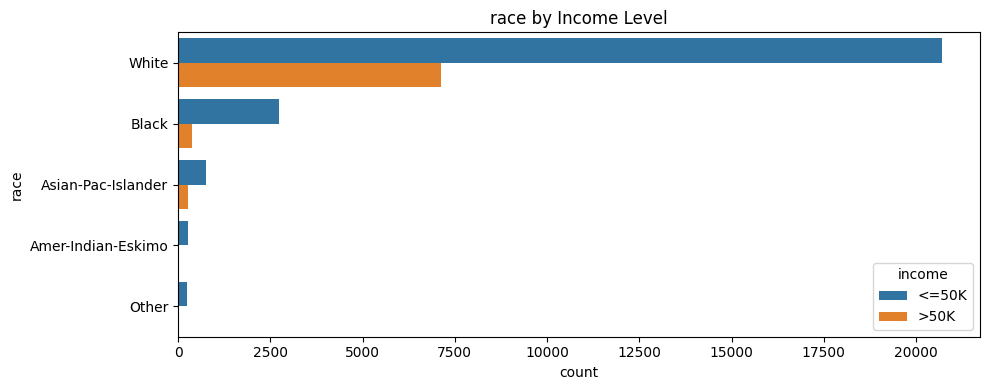

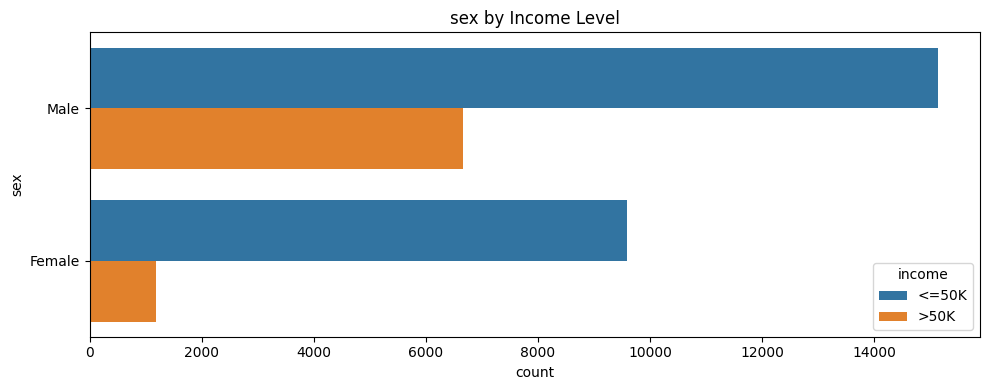

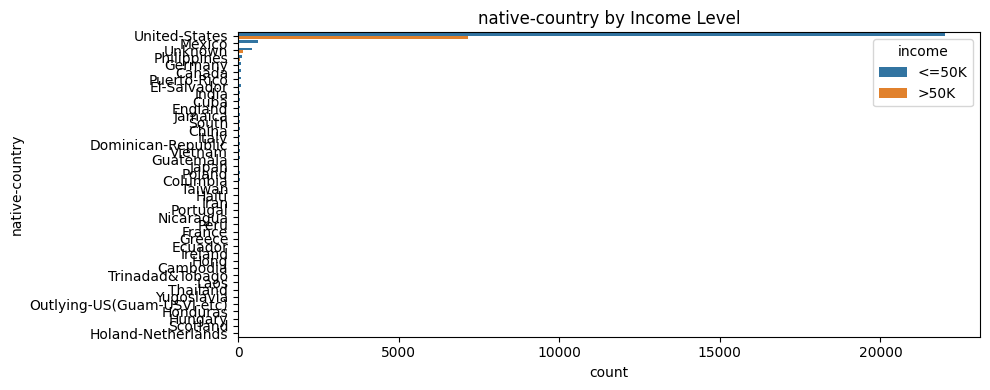

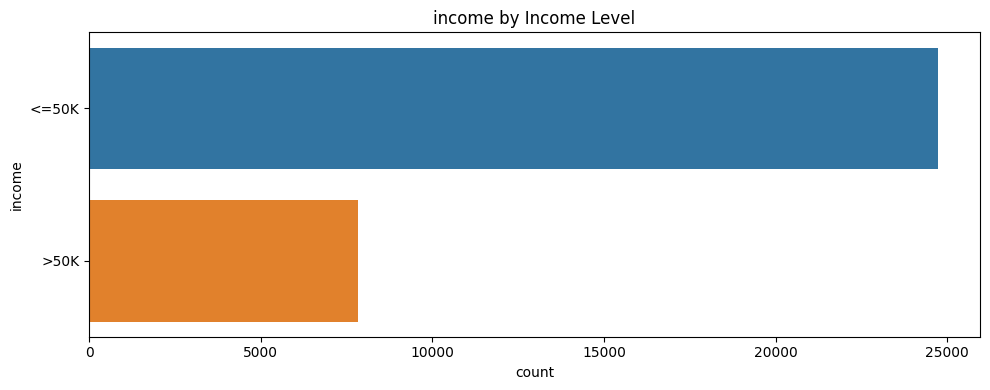

In [14]:
# Categorical vs Target variable analysis
for col in catergorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(y=df[col], hue=df['income'], order=df[col].value_counts().index)
    plt.title(f'{col} by Income Level')
    plt.tight_layout()
    plt.show()

### Correlation heatmap

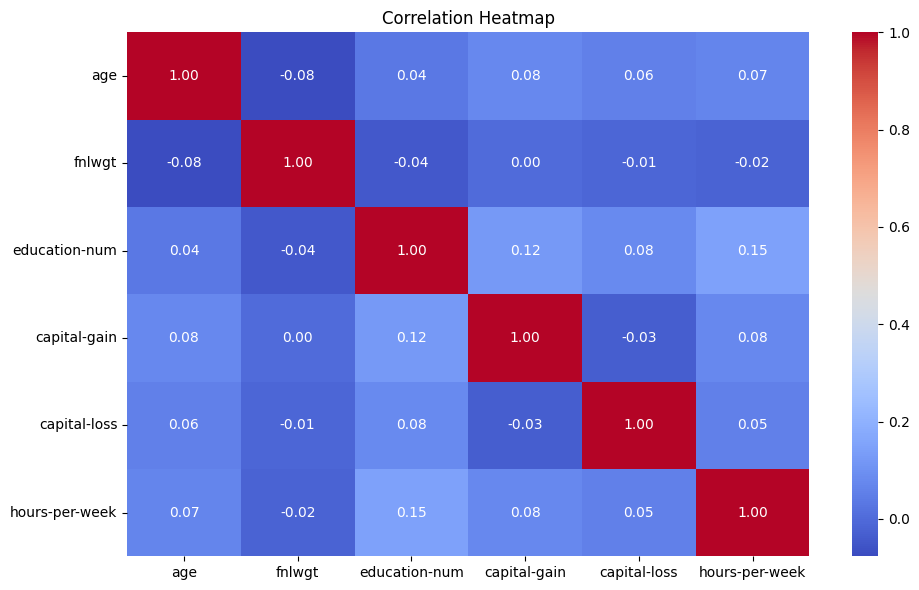

In [15]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### How EDA affects feature engineering

Now that we've explored the data, we have a clear understanding and reasoning for our feature engineering that helps us decide which techniques to apply on which attributes and other relevant decisions:

- Many 0s and few high values in capital-gain/capital-loss, so we can combine into one attribute net_capital
- Married people earn more, so we can encode marital status into a binary feature of "married vs not"
- native-country is mostly U.S., so create binary feature is_US
- education and education-num are redundant so we can drop one
- fnlwgt doesn't really correlate with the target variable so we can drop
- We can one-hot encode the categorical variables such as workclass, occupation, etc.
- sex influences income so can encode it as binary 1/0

## Feature Engineering

In [16]:
df_new = df.copy()

# Drop irrelevant columns
df_new.drop(columns=['education'], inplace=True)

### Creating new features

In [ ]:
# Add interaction terms
df_new['age_edu_interact'] = df_new['age'] * df['education-num']
df_new['hours_occ_interact'] = df_new['hours-per-week'] * (df_new['occupation'].astype('category').cat.codes + 1)


# Marital Status Simplification
df_new['is_married'] = df_new['marital-status'].apply(lambda x: 1 if 'Married' in x else 0)

# Native Country Grouping
df_new['is_US'] = (df_new['native-country'] == 'United-States').astype(int)

# Binary encoding for sex
df_new['sex'] = df_new['sex'].map({'Male': 1, 'Female': 0})

# Drop original columns
df_new = df_new.drop(['marital-status', 'native-country'], axis=1)


In [18]:
# Categorical encoding
categorical_cols = ['workclass', 'occupation', 'relationship', 'race']
df_new = pd.get_dummies(df_new, columns=categorical_cols, drop_first=True)

df_new.head()
df_new.info()
df_new.select_dtypes(include='object').columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   age                           32561 non-null  int64 
 1   fnlwgt                        32561 non-null  int64 
 2   education-num                 32561 non-null  int64 
 3   sex                           32561 non-null  int64 
 4   capital-gain                  32561 non-null  int64 
 5   capital-loss                  32561 non-null  int64 
 6   hours-per-week                32561 non-null  int64 
 7   income                        32561 non-null  object
 8   age_edu_interact              32561 non-null  int64 
 9   hours_occ_interact            32561 non-null  int64 
 10  is_married                    32561 non-null  int64 
 11  is_US                         32561 non-null  int32 
 12  workclass_Local-gov           32561 non-null  bool  
 13  workclass_Never-

Index(['income'], dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Encode target
df_new['income'] = df_new['income'].map({'<=50K': 0, '>50K': 1})

X = df_new.drop('income', axis=1)
y = df_new['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rs = RandomizedSearchCV(
    rf, param_distributions=param_dist, n_iter=20, cv=5,
    random_state=42, scoring='accuracy', n_jobs=-1
)

rs.fit(X_train, y_train)

best_rf = rs.best_estimator_
print("Best parameters found:", rs.best_params_)

# ---------------------------------------------
# 6. Model evaluation
# ---------------------------------------------
y_pred = best_rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Best parameters found: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
Accuracy: 0.8676493167511131


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92      4945
           1       0.78      0.63      0.70      1568

    accuracy                           0.87      6513
   macro avg       0.83      0.79      0.81      6513
weighted avg       0.86      0.87      0.86      6513



In [ ]:
# --- BASELINE MODEL ---
df_base = df.copy()

# Encode categorical columns using one-hot encoding 
cat_cols = df_base.select_dtypes(include='object').columns.drop('income')
df_base = pd.get_dummies(df_base, columns=cat_cols, drop_first=True)

# Encode target
df_base['income'] = df_base['income'].map({'<=50K': 0, '>50K': 1})

# Split
X_base = df_base.drop('income', axis=1)
y_base = df_base['income']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

# Train
model_base = RandomForestClassifier(n_estimators=100, random_state=42)
model_base.fit(Xb_train, yb_train)
yb_pred = model_base.predict(Xb_test)

print("Baseline Accuracy:", accuracy_score(yb_test, yb_pred))


Baseline Accuracy: 0.8616612927990174
